# SVM (one-vs-all, lineaire)

Plan :
1. Cas logiques : OR, AND (lineairement separables), XOR, XNOR (non separables)
2. Frontiere de decision : OR vs XOR
3. Cas non lineaire (cercle) -- limite du SVM lineaire, et kernel trick (RBF) pour la depasser
4. Marge souple (C) -- donnees qui se chevauchent
5. Sauvegarde et chargement du modele

In [1]:
import os
import sys
sys.path.append(os.path.abspath(os.path.join("..", "python")))

import numpy as np
import matplotlib.pyplot as plt
from svm import lib, entrainer_svm, predire_svm, precision_svm


def dessiner_frontiere(model, X, labels, titre):
    """Affiche la frontiere de decision du modele sur des points 2D"""
    X = np.array(X, dtype=float)
    pas = 0.05
    valeurs_x = np.arange(X[:, 0].min() - 0.3, X[:, 0].max() + 0.3, pas)
    valeurs_y = np.arange(X[:, 1].min() - 0.3, X[:, 1].max() + 0.3, pas)

    Z = [[predire_svm(model, [x, y]) for x in valeurs_x] for y in valeurs_y]

    plt.contourf(valeurs_x, valeurs_y, Z, alpha=0.3, cmap="coolwarm")
    plt.scatter(X[:, 0], X[:, 1], c=labels, cmap="coolwarm", edgecolors="k", s=80)
    plt.title(titre)
    plt.show()

## 1. Cas logiques

In [2]:
inputs = [[0.0, 0.0], [0.0, 1.0], [1.0, 0.0], [1.0, 1.0]]
portes = {"OR": [0, 1, 1, 1], "AND": [0, 0, 0, 1], "XOR": [0, 1, 1, 0], "XNOR": [1, 0, 0, 1]}

for nom, labels in portes.items():
    model = entrainer_svm(inputs, labels, nb_classes=2)
    preds = [predire_svm(model, x) for x in inputs]
    lib.destroy_svm_model(model)
    print(f"{nom:5s} attendu={labels}  predit={preds}")

OR    attendu=[0, 1, 1, 1]  predit=[0, 1, 1, 1]
AND   attendu=[0, 0, 0, 1]  predit=[0, 0, 0, 1]
XOR   attendu=[0, 1, 1, 0]  predit=[0, 0, 0, 0]
XNOR  attendu=[1, 0, 0, 1]  predit=[1, 1, 1, 1]


## 2. Frontiere de decision : OR vs XOR

Le SVM ici est **lineaire** (produit scalaire simple, pas de noyau) : il ne peut
tracer qu'une droite. OR est lineairement separable, XOR ne l'est pas

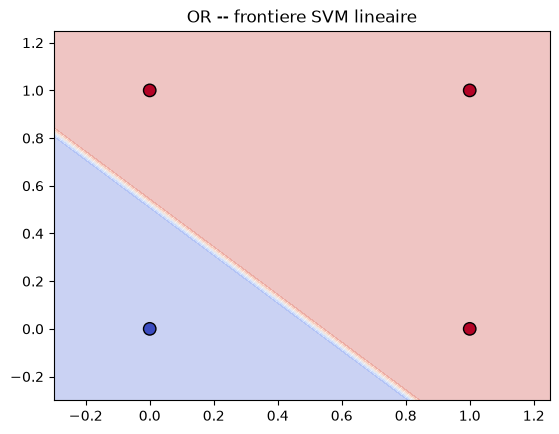

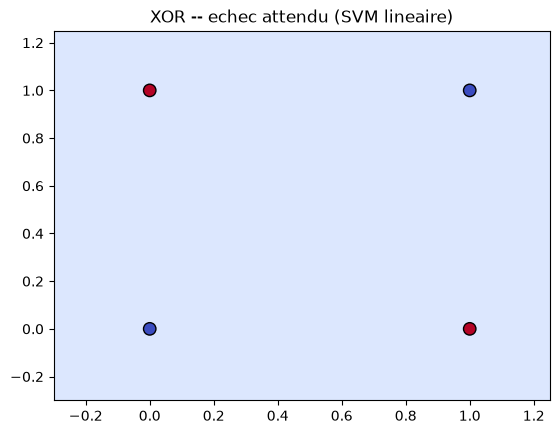

In [3]:
inputs = [[0.0, 0.0], [0.0, 1.0], [1.0, 0.0], [1.0, 1.0]]

labels_or = [0, 1, 1, 1]
model_or = entrainer_svm(inputs, labels_or, nb_classes=2)
dessiner_frontiere(model_or, inputs, labels_or, "OR -- frontiere SVM lineaire")
lib.destroy_svm_model(model_or)

labels_xor = [0, 1, 1, 0]
model_xor = entrainer_svm(inputs, labels_xor, nb_classes=2)
dessiner_frontiere(model_xor, inputs, labels_xor, "XOR -- echec attendu (SVM lineaire)")
lib.destroy_svm_model(model_xor)

## 3. Cas non lineaire (cercle) - kernel trick

Le SVM lineaire echoue par
construction. Le noyau RBF (kernel trick) projette implicitement les points
dans un espace ou ils deviennent separables -> la frontiere redevient une
courbe fermee dans l'espace d'origine.

Precision SVM lineaire (cercle) : 50.0 %


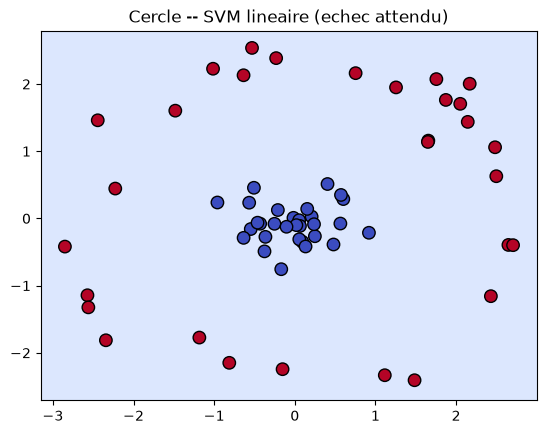

Precision SVM kernel RBF (cercle) : 100.0 %


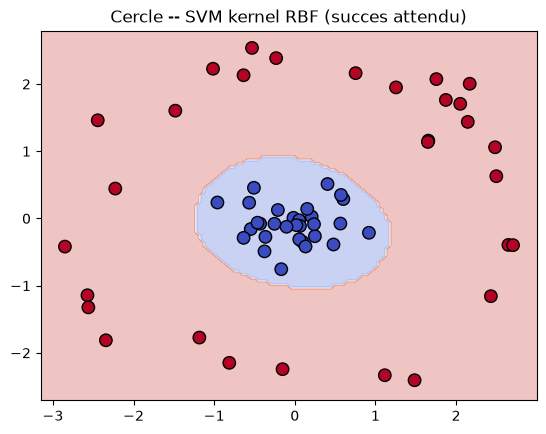

In [4]:
np.random.seed(0)
n = 30

angles_in = np.random.uniform(0, 2*np.pi, n)
rayons_in = np.random.uniform(0, 1.0, n)
points_in = np.column_stack([rayons_in*np.cos(angles_in), rayons_in*np.sin(angles_in)])

angles_out = np.random.uniform(0, 2*np.pi, n)
rayons_out = np.random.uniform(2.0, 3.0, n)
points_out = np.column_stack([rayons_out*np.cos(angles_out), rayons_out*np.sin(angles_out)])

X_cercle = np.vstack([points_in, points_out]).tolist()
y_cercle = [0]*n + [1]*n

model_lin = entrainer_svm(X_cercle, y_cercle, nb_classes=2, kernel="lineaire")
print("Precision SVM lineaire (cercle) :", precision_svm(model_lin, X_cercle, y_cercle), "%")
dessiner_frontiere(model_lin, X_cercle, y_cercle, "Cercle -- SVM lineaire (echec attendu)")
lib.destroy_svm_model(model_lin)

model_rbf = entrainer_svm(X_cercle, y_cercle, nb_classes=2, kernel="rbf", gamma=0.5)
print("Precision SVM kernel RBF (cercle) :", precision_svm(model_rbf, X_cercle, y_cercle), "%")
dessiner_frontiere(model_rbf, X_cercle, y_cercle, "Cercle -- SVM kernel RBF (succes attendu)")
lib.destroy_svm_model(model_rbf)

## 4. Marge souple (donnees qui se chevauchent)

Deux nuages de points qui se chevauchent legerement - pas de separation
parfaite possible, meme avec un bon noyau. Le parametre `C` controle la
tolerance aux erreurs : `C` grand (~marge dure) force a coller aux donnees,
`C` petit (~marge souple) accepte quelques erreurs pour garder une frontiere
plus simple et plus generale.

C=1000000000.0 precision = 92.5%


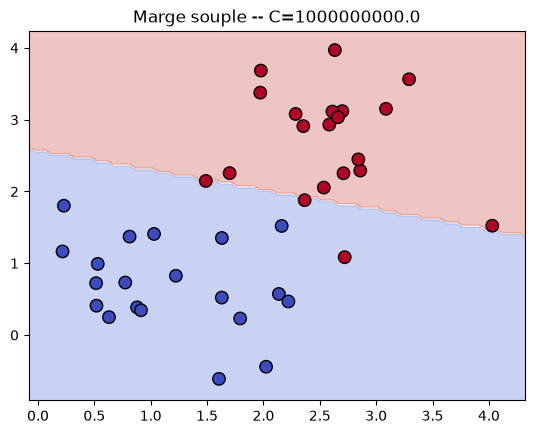

C=1.0      precision = 95.0%


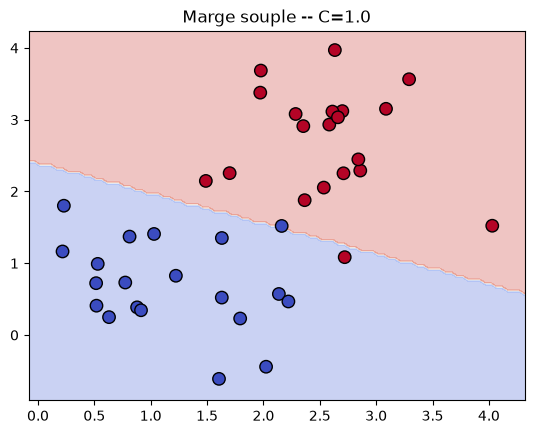

C=0.1      precision = 95.0%


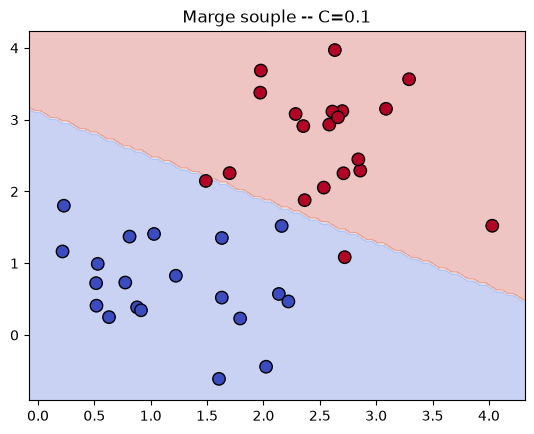

In [5]:
np.random.seed(1)
n = 20
classe_a = np.random.normal(loc=[1, 1], scale=0.7, size=(n, 2))
classe_b = np.random.normal(loc=[2.5, 2.5], scale=0.7, size=(n, 2))
X_chevauche = np.vstack([classe_a, classe_b]).tolist()
y_chevauche = [0]*n + [1]*n

for C in [1e9, 1.0, 0.1]:
    model = entrainer_svm(X_chevauche, y_chevauche, nb_classes=2, kernel="lineaire", C=C)
    p = precision_svm(model, X_chevauche, y_chevauche)
    print(f"C={C:<8} precision = {p:.1f}%")
    dessiner_frontiere(model, X_chevauche, y_chevauche, f"Marge souple -- C={C}")
    lib.destroy_svm_model(model)

## 5. Sauvegarde et chargement du modele

In [6]:
os.makedirs(os.path.join("..", "models"), exist_ok=True)
chemin = os.path.join("..", "models", "svm_or.txt")

model = entrainer_svm(inputs, labels_or, nb_classes=2)
lib.save_svm(model, chemin.encode())
lib.destroy_svm_model(model)

model_charge = lib.load_svm(chemin.encode())
preds = [predire_svm(model_charge, x) for x in inputs]
lib.destroy_svm_model(model_charge)
print("attendu :", labels_or)
print("predit  :", preds)

attendu : [0, 1, 1, 1]
predit  : [0, 1, 1, 1]
